# 关于本 Notebook

本 Notebook 使用 **LangGraph** 和 **LangChain** 构建一个分层的团队式智能体系统（hierarchical, team-based agent system）。它能够进行网页研究、页面抓取、专利搜索、代码执行，并通过协作撰写报告并将结果持久化到磁盘。示例重点展示：如何在一个**顶层主管（Top-level Supervisor）**之下组合多个子图（subgraphs），同时让工具、角色和状态都保持显式可见。

## 本 Notebook 展示什么

* **两个专业团队（specialized teams）**，由各自的 Supervisor 协调

  1. **研究团队（Research Team）**：负责搜索、网页抓取、Exa 语义搜索和 Google Patents 检索
  2. **文档写作团队（Document Writing Team）**：负责创建大纲、读取/写入/编辑文档，以及使用 Python REPL 生成简单图表
* **顶层编排器（Top-level Orchestrator）**：在两个团队之间路由任务并汇总结果
* **混合工具栈（Tooling Mix）**：Tavily、SerpAPI、Exa、WebBaseLoader 抓取和 Python REPL
* **文件持久化（File Persistence）**：在工作目录中保存大纲和最终报告
* **流式执行（Streaming Runs）**：逐步打印执行更新，并为每个团队和顶层主管图生成 **Mermaid PNG** 预览

## 你将运行什么

1. 定义研究工具

   * 使用 `tavily_tool` 获取搜索结果
   * 使用 `scrape_webpages` 抓取并拼接网页内容
   * 通过 SerpAPI Google Patents 使用 `patent_search` 搜索专利
   * 使用 `exa_search_tool` 进行神经语义搜索并返回高亮片段
2. 定义文档工具

   * `create_outline`、`read_document`、`write_document`、`edit_document`：在受限工作目录中操作文件
   * `python_repl_tool`：进行快速计算或生成图表，并把结果打印到 stdout
3. 使用 `create_react_agent` 构建**工作节点（worker nodes）**，并使用带结构化路由输出的 **LLM Supervisor** 决定下一个 Worker，或选择结束。
4. 编译三个图

   * `research_graph`：负责网页研究与专利搜索
   * `paper_writing_graph`：负责大纲与写作，可选生成图表
   * `super_graph`：端到端编排两个团队
5. 运行示例

   * 让研究团队调查 AI Agents 与相关专利
   * 让写作团队把一首诗写入磁盘
   * 运行完整任务：生成一篇约 800 词的半导体白皮书，包含专利链接与来源，并保存为 `semiconductor_whitepaper.txt`

## 工作原理

* **Supervisor（主管）**：使用结构化输出的小型 LLM 路由器，从固定 Worker 集合中选择下一步，或返回 `FINISH`。
* **Worker（工作智能体）**：绑定特定工具集与 Prompt 的 ReAct 风格智能体。每个 Worker 返回一条精简消息，再交回 Supervisor。
* **State（状态）**：使用 `MessagesState`，并额外维护一个简单的 `next` 字段。消息可以跨团队流动，使顶层 Supervisor 能够完成协调。
* **Routing（路由）**：通过 `Command(goto=..., update=...)` 实现，在追加结果到状态的同时决定跳转到哪个节点。
* **Persistence（持久化）**：文件工具都在 `WORKING_DIRECTORY` 下读写。最终任务会把完整报告写入磁盘。

## 为什么使用这种模式

* 清晰的职责分离让行为更可预测、更容易测试。
* Supervisor 让控制流保持显式，并便于审计。
* 每个 Worker 只绑定自己的工具集，能够减少 Prompt 膨胀并提升可靠性。
* 顶层图可以组合不同团队，而不必耦合它们的内部实现。

## 如何扩展与改造

* 在研究团队与写作团队之间增加引用校验器（citation validator）。
* 替换或增加搜索服务商。
* 用沙箱执行器替换 Python REPL。
* 使用 LangSmith 持久化检查点（checkpoints）和追踪（traces），用于调试与评估。

## 环境要求与说明

* 所需密钥：`OPENAI_API_KEY`、`TAVILY_API_KEY`、`SERPAPI_API_KEY`、`EXA_API_KEY`。
* 网页结果和专利列表会随时间变化，因此每次运行的输出可能不同。
* 文件系统工具会写入工作目录。对于不可信内容，请放在沙箱或 Docker 环境中运行。
* 流式输出会打印中间步骤，便于追踪路由决策与工具调用。


In [ ]:
%%capture --no-stderr
%pip install -U langgraph langchain_community langchain_openai langchain-tavily langchain_experimental python-dotenv exa_py==1.16.1

In [ ]:
# API 相关导入
from dotenv import load_dotenv
import os

load_dotenv()

NEBIUS_API_KEY = os.getenv('NEBIUS_API_KEY')
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
serp_api_key = os.getenv("SERPAPI_API_KEY")
SERPER_API_KEY = os.getenv("SERPER_API_KEY")
exa_api_key = os.getenv("EXA_API_KEY")

In [ ]:
!pip install tavily-python

<div class="admonition tip">
    <p class="admonition-title">为 LangGraph 开发配置 <a href="https://smith.langchain.com">LangSmith</a></p>
    <p style="padding-top: 5px;">
        注册 LangSmith 可以帮助你快速发现问题，并改进 LangGraph 项目的性能。LangSmith 能利用追踪数据（trace data）调试、测试和监控基于 LangGraph 构建的 LLM 应用——关于如何开始使用，请阅读<a href="https://docs.smith.langchain.com">这里</a>。
    </p>
</div>

## 创建工具

每个团队都由一个或多个 Agent 组成，每个 Agent 又可以拥有一个或多个工具。下面先定义不同团队会使用到的全部工具。

我们从研究团队开始。

**Research Team 工具**

研究团队可以使用搜索引擎和 URL 抓取工具从互联网上查找信息。你也可以在下面继续添加能力，以进一步提升团队表现。

In [ ]:
from typing import Annotated, List

from langchain_community.document_loaders import WebBaseLoader
from langchain_tavily import TavilySearch
from langchain_core.tools import tool




In [ ]:
import os
import datetime
from typing import Dict, Any

from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch, TavilyExtract

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import StreamWriter
from langgraph.prebuilt import ToolNode

from langchain_core.messages import HumanMessage, AIMessage


**文档写作团队工具（Document Writing Team Tools）**

接下来，为文档写作团队提供一组可调用的工具。
下面定义一些基础的文件访问工具。

请注意，这会让 Agent 获得访问本地文件系统的能力，因此可能带来安全风险。此外，这里也没有针对性能优化工具描述。

In [ ]:
from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Optional

from typing_extensions import TypedDict
from langchain_community.tools.tavily_search import TavilySearchResults
from typing import Annotated, List

from langchain_community.document_loaders import WebBaseLoader
from langchain_tavily import TavilySearch
from langchain_core.tools import tool


# 定义持久化工作目录
WORKING_DIRECTORY = Path("/content/working_directory")

# 确保工作目录存在
if not WORKING_DIRECTORY.exists():
    WORKING_DIRECTORY.mkdir(parents=True)
    print(f"Created working directory: {WORKING_DIRECTORY}")
else:
    print(f"Working directory already exists: {WORKING_DIRECTORY}")

from langchain_community.utilities import SerpAPIWrapper
from exa_py import Exa
import json
from typing import List

import re
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from langchain_core.tools import tool
from typing import List

# --- 加载编码器模型（Analyst 的"大脑"）---
# 只在启动时执行一次。
try:
    print("Loading Analyst (ModernBERT) model...")
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 使用指定的模型
    tok = AutoTokenizer.from_pretrained("answerdotai/ModernBERT-base", use_fast=True)
    enc = AutoModel.from_pretrained("answerdotai/ModernBERT-base", trust_remote_code=True).eval().to(device)

    print(f"Analyst (ModernBERT) loaded successfully on {device}.")
except Exception as e:
    print(f"Warning: Could not load ModernBERT. Analyst will not work. Error: {e}")
    # 定义占位对象，避免后续代码直接崩溃
    tok, enc, device = None, None, "cpu"


def _sent_split(text):
    """A simple, fast sentence splitter"""
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if len(s.strip()) > 0]

@tool("semantic_filter_tool")
def semantic_filter_tool(query: str, documents: List[str], k: int = 10) -> str:
    """
    The Analyst's tool. Uses ModernBERT (an encoder model) to perform
    extractive summarization. It finds the top 'k' most relevant sentences
    from a list of documents that match a specific query.
    """
    if not enc:
        return "Error: ModernBERT model is not loaded."

    print(f"--- 🕵️ Analyst (ModernBERT) processing {len(documents)} docs... ---")

    # 1. 创建带来源信息（provenance）的句子库
    bank, provenance = [], []
    for i, doc_text in enumerate(documents):
        for s in _sent_split(doc_text):
            bank.append(s)
            provenance.append(f"Source Doc [{i}]") # 记录句子的来源

    if not bank:
        return "No text found in documents."

    # 2. 编码查询与句子库中的全部句子
    batch = [query] + bank
    inputs = tok(batch, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.no_grad():
        H = enc(**inputs).last_hidden_state
        attn = inputs["attention_mask"].unsqueeze(-1)
        # 通过平均池化得到句向量（sentence embeddings）
        emb = (H * attn).sum(dim=1) / attn.sum(dim=1)

    q = emb[0]  # 查询向量
    S = emb[1:] # 句向量

    # 3. 根据与查询的相似度为句子打分
    score = F.cosine_similarity(S, q.unsqueeze(0)).flatten()

    # 4. 选出得分最高的 k 个句子
    top_k_indices = torch.topk(score, k=min(k, len(bank))).indices

    # 5. 格式化输出
    results = []
    for idx in top_k_indices:
        i = idx.item()
        results.append({
            "text": bank[i],
            "source": provenance[i],
            "score": round(score[i].item(), 4)
        })

    return json.dumps(results, indent=2)


tavily_search = TavilySearch(
    max_results=10,
    topic="general",
    search_depth="basic",
)

tavily_extract = TavilyExtract(
    extract_depth="advanced",
    include_images=False,
)

@tool
def scrape_webpages(urls: List[str]) -> str:
    """Use requests and bs4 to scrape the provided web pages for detailed information."""
    loader = WebBaseLoader(urls)
    docs = loader.load()
    return "\n\n".join(
        [
            f'<Document name="{doc.metadata.get("title", "")}">\n{doc.page_content}\n</Document>'
            for doc in docs
        ]
    )

from langchain_community.utilities import GoogleSerperAPIWrapper

_serper = GoogleSerperAPIWrapper(type="search", hl="en", gl="us", tbs="qdr:y")

@tool("patent_search")
def patent_search(topic: str, max_items: int = 10) -> str:
    """
    Past-year Google Patents hits via Serper. Returns JSON with title, link, date, snippet.
    """
    q = f'site:patents.google.com ("{topic}")'
    res = _serper.results(q)
    organics = res.get("organic", [])
    hits = [
        {
            "title": o.get("title",""),
            "link": o.get("link",""),
            "date": o.get("date") or o.get("publishedDate") or o.get("publishedTime"),
            "snippet": o.get("snippet",""),
        }
        for o in organics if "patents.google.com" in o.get("link","")
    ][:max_items]
    if not hits:
        return "No recent Google Patents results found."
    return json.dumps(hits, indent=2)



@tool("exa_search_tool")
def exa_search_tool(question: str) -> str:
    """Tool using Exa's Python SDK to run semantic search and return result highlights."""
    exa = Exa(exa_api_key)

    response = exa.search_and_contents(
        question,
        type="neural",
        use_autoprompt=True,
        num_results=5,
        highlights=True
    )

    results = []
    for idx, eachResult in enumerate(response.results):
        result = {
            "Title": eachResult.title,
            "URL": eachResult.url,
            "Highlight": "".join(eachResult.highlights)
        }
        results.append(result)

    return json.dumps(results)


@tool
def create_outline(
    points: Annotated[List[str], "List of main points or sections."],
    file_name: Annotated[str, "File path to save the outline."],
) -> Annotated[str, "Path of the saved outline file."]:
    """Create and save an outline."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        for i, point in enumerate(points):
            file.write(f"{i + 1}. {point}\n")
    return f"Outline saved to {file_name}"


@tool
def read_document(
    file_name: Annotated[str, "File path to read the document from."],
    start: Annotated[Optional[int], "The start line. Default is 0"] = None,
    end: Annotated[Optional[int], "The end line. Default is None"] = None,
) -> str:
    """Read the specified document."""
    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()
    if start is None:
        start = 0
    return "\n".join(lines[start:end])


@tool
def write_document(
    content: Annotated[str, "Text content to be written into the document."],
    file_name: Annotated[str, "File path to save the document."],
) -> Annotated[str, "Path of the saved document file."]:
    """Create and save a text document."""
    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.write(content)
    return f"Document saved to {file_name}"


@tool
def edit_document(
    file_name: Annotated[str, "Path of the document to be edited."],
    inserts: Annotated[
        Dict[int, str],
        "Dictionary where key is the line number (1-indexed) and value is the text to be inserted at that line.",
    ],
) -> Annotated[str, "Path of the edited document file."]:
    """Edit a document by inserting text at specific line numbers."""

    with (WORKING_DIRECTORY / file_name).open("r") as file:
        lines = file.readlines()

    sorted_inserts = sorted(inserts.items())

    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number - 1, text + "\n")
        else:
            return f"Error: Line number {line_number} is out of range."

    with (WORKING_DIRECTORY / file_name).open("w") as file:
        file.writelines(lines)

    return f"Document edited and saved to {file_name}"



Working directory already exists: /content/working_directory
Loading Analyst (ModernBERT) model...
Analyst (ModernBERT) loaded successfully on cuda.


## 辅助工具函数（Helper Utilities）

接下来创建几个辅助函数，让下面两类操作写起来更简洁：

1. 创建 Worker Agent。
2. 为子图创建 Supervisor。

这样可以简化后面的图组合代码，让整体结构更容易阅读和理解。

In [ ]:
from typing import List, Optional, Literal
from langchain_core.language_models.chat_models import BaseChatModel
import operator
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.types import Command
from langchain_core.messages import HumanMessage, trim_messages
from langchain_core.messages import BaseMessage

class State(MessagesState):
    # 跟踪团队内部对话
    messages: Annotated[List[BaseMessage], operator.add]
    # 向每个 Worker 提供其他成员能力范围的上下文
    members: str
    # Supervisor 通过该字段告诉 LangGraph 下一步由谁执行
    next: str
    # 跟踪共享目录状态
    current_files: str

def make_supervisor_node(llm: BaseChatModel, members: list[str]) -> str:
    options = ["FINISH"] + members
    system_prompt = (
    "You are the Thinker, a supervisor.\n"
    "you have the following team members: {members}"
    "Default order: search -> exa_search -> patent_research -> analyst -> note_taker -> doc_writer -> FINISH.\n"
    "Only send the analyst after at least one research worker returned content.\n"
    "When finished, write key findings to file via doc_writer. Cite sources."
)


    class Router(TypedDict):
        """Worker to route to next. If no workers needed, route to FINISH."""

        next: Literal[*options]

    def supervisor_node(state: State) -> Command[Literal[*members, "__end__"]]:
        """An LLM-based router."""
        messages = [
            {"role": "system", "content": system_prompt},
        ] + state["messages"]
        response = llm.with_structured_output(Router).invoke(messages)
        goto = response["next"]
        if goto == "FINISH":
            goto = END

        return Command(goto=goto, update={"next": goto})

    return supervisor_node

In [ ]:
from __future__ import annotations
from typing import Any, Dict, Literal, Sequence
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
from langgraph.types import Command

def make_react_worker_node(
    *,
    llm: ChatOpenAI,
    name: str,
    tools: list,
    prompt: str | None = None,
    goto: str = "supervisor",
):
    agent = create_react_agent(llm, tools=tools, prompt=prompt)

    def node(state: State) -> Command[Literal["supervisor"]]:
        result: Dict[str, Any] = agent.invoke(state)
        msgs: Sequence[BaseMessage] = result.get("messages", [])
        content = getattr(msgs[-1], "content", "") if msgs else ""
        return Command(
            update={"messages": [HumanMessage(content=content, name=name)]},
            goto=goto,
        )

    return node


## 定义智能体团队（Agent Teams）

现在可以开始定义分层团队了。也就是："Choose your player!"

### 研究团队（Research Team）

研究团队会包含搜索 Agent 和负责网页抓取的 `research_agent`，它们作为两个 Worker 节点。下面创建这些 Worker，以及负责协调它们的团队 Supervisor。

必要组件创建完成后，定义它们之间的交互就很直接了：把节点加入团队图，再定义边（edges），由这些边决定节点之间的转移条件。

In [ ]:
fast_llm = ChatOpenAI(
    model="Qwen/Qwen3-32B-fast",
    temperature=0,
    api_key=NEBIUS_API_KEY,
    base_url="https://api.studio.nebius.ai/v1/",
    extra_body={
        "top_k": 20,
        "chat_template_kwargs": {"enable_thinking": False},
    },
)


thinker_llm = ChatOpenAI(
    model="Qwen/Qwen3-235B-A22B-Thinking-2507",
    temperature=0,
    api_key=NEBIUS_API_KEY,
    base_url="https://api.studio.nebius.ai/v1/",
    # 让思考过程保持内部化，并限制其规模
    extra_body={
        "chat_template_kwargs": {"enable_thinking": True},
        # 设置思考预算
        "thinking": {"type": "token", "budget": 1536}
    },
)

supervisor_llm = ChatOpenAI(
    model="gpt-4.1",
    temperature=0
)

In [ ]:
# Prompt 用于保持角色边界清晰
#SEARCH_PROMPT = """Role: Web researcher. Use the search tool and return a
#concise research note with sources. No follow-up questions."""

today = datetime.datetime.now().strftime("%Y-%m-%d")
SEARCH_PROMPT = f"""
You are a precise research agent. The date is {today}.
When the user asks for sources from a specific site or domain, pass that intent to the Tavily search tool using include_domains.
Typical flow:
1 search with TavilySearch to find relevant pages
2 extract with TavilyExtract on the top results
3 write a clear synthesis with short bullet points and inline bracketed citations pointing to the URLs you actually used
Be concise and evidence based.
""".strip()

EXA_PROMPT = """Role: Research assistant. You can search for all recent info
on Exa Search. Your response should clearly articulate the key points you found."""

PATENT_PROMPT = """Role: Market researcher with 20 years of experience.
You are very knowledgeable in patent research and in finding up-to-date info
about patents using the Google Patents API."""

NOTE_PROMPT = """You can read documents and create outlines for the document
writer. Don't ask follow-up questions."""

WRITER_PROMPT = """You can read, write and edit documents based on note-taker's
outlines. Don't ask follow-up questions."""

ANALYST_PROMPT = """
You are the Analyst. You must call the `semantic_filter_tool` exactly once.
Inputs:
- query: the current task topic or question
- documents: a list of raw strings gathered by teammates

Rules:
- Do not answer the user
- Do not do free form writing
- Only return the tool result to the supervisor
""".strip()


specs = [
    dict(name="search",          tools=[tavily_search, tavily_extract], prompt=SEARCH_PROMPT,      llm=fast_llm),
    dict(name="exa_search",      tools=[exa_search_tool],               prompt=EXA_PROMPT,         llm=fast_llm),
    dict(name="patent_research", tools=[patent_search],                 prompt=PATENT_PROMPT,      llm=fast_llm),
    dict(name="analyst",         tools=[semantic_filter_tool],          prompt=ANALYST_PROMPT,     llm=thinker_llm),
    dict(name="note_taker",      tools=[create_outline, read_document], prompt=NOTE_PROMPT,        llm=fast_llm),
    dict(name="doc_writer",      tools=[write_document, edit_document, read_document], prompt=WRITER_PROMPT, llm=fast_llm),
]

nodes = {
    s["name"]: make_react_worker_node(llm=s["llm"], name=s["name"], tools=s["tools"], prompt=s["prompt"])
    for s in specs
}


search_node = nodes["search"]
exa_search_node = nodes["exa_search"]
patent_research_node = nodes["patent_research"]
analyst_node = nodes["analyst"]
note_taking_node = nodes["note_taker"]
doc_writing_node = nodes["doc_writer"]

# 可协调这些 Worker 的 Supervisor
research_supervisor_node = make_supervisor_node(
    supervisor_llm, ["exa_search", "patent_research", "analyst", "note_taker", "doc_writer"]
)


/tmp/ipython-input-3604616990.py:16: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(llm, tools=tools, prompt=prompt)


In [ ]:
research_builder = StateGraph(State)

# 注册节点
research_builder.add_node("supervisor", research_supervisor_node)
research_builder.add_node("exa_search", exa_search_node)
research_builder.add_node("patent_research", patent_research_node)
research_builder.add_node("analyst", analyst_node)
research_builder.add_node("note_taker", note_taking_node)
research_builder.add_node("doc_writer", doc_writing_node)

# --- 定义边 ---
research_builder.add_edge(START, "supervisor")
research_builder.add_edge("exa_search", "supervisor")
research_builder.add_edge("patent_research", "supervisor")
research_builder.add_edge("analyst", "supervisor")
research_builder.add_edge("note_taker", "supervisor")
research_builder.add_edge("doc_writer", "supervisor")


research_graph = research_builder.compile()

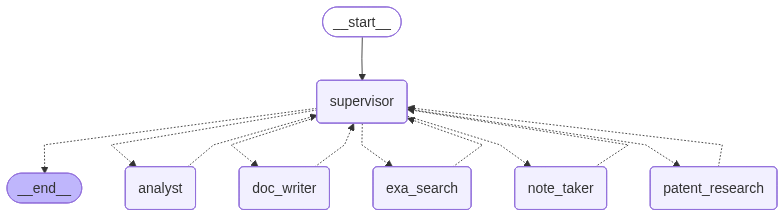

In [ ]:
from IPython.display import Image, display

display(Image(research_graph.get_graph().draw_mermaid_png()))

现在可以直接把任务交给这个团队。下面实际运行一次。

In [ ]:
for s in research_graph.stream(
    {"messages": [("user", """ Research the latest developments in AI agents,
    specifically coding agents. Write at least 500 words about the findings.
    Include patents! And include all links to references!
    """)]},
    {"recursion_limit": 100},
):
    print(s)
    print("---")


{'supervisor': {'next': 'exa_search'}}
---
{'exa_search': {'messages': [HumanMessage(content='### Latest Developments in AI Agents: A Focus on Coding Agents\n\nAI agents, particularly those focused on coding, are rapidly evolving and transforming the landscape of software development. These agents, powered by large language models (LLMs), are capable of autonomously planning, executing, and interacting with various tools such as compilers, debuggers, and version control systems. This paradigm shift is not just about generating code but involves decomposing complex tasks into manageable steps, coordinating multi-step processes, and adapting based on feedback. The implications of these advancements are profound, as they promise to reshape traditional software development practices.\n\n#### AI Agentic Programming\n\nA recent survey titled "AI Agentic Programming: A Survey of Techniques, Challenges, and Opportunities" provides a comprehensive overview of the field. The authors, from the Un

/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:282: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
W1102 12:49:47.802000 1518 torch/_inductor/utils.py:1436] [1/0_1] Not enough SMs to use max_autotune_gemm mode


{'analyst': {'messages': [HumanMessage(content='\n\n[\n  {\n    "text": "### Patents on AI Agents\\n\\nWhile the provided search results do not explicitly mention patents on AI agents, it is worth noting that the field of AI is rapidly evolving, and numerous patents are likely being filed to protect innovations in this area.",\n    "source": "Source Doc [1]",\n    "score": 0.9658\n  },\n  {\n    "text": "### Patents on AI Agents\\n\\nWhile the provided search results do not explicitly mention patents on AI agents, it is worth noting that the field of AI is rapidly evolving, and numerous patents are likely being filed to protect innovations in this area.",\n    "source": "Source Doc [0]",\n    "score": 0.9658\n  },\n  {\n    "text": "### Latest Developments in AI Agents: A Focus on Coding Agents\\n\\nAI agents, particularly those focused on coding, are rapidly evolving and transforming the landscape of software development.",\n    "source": "Source Doc [0]",\n    "score": 0.956\n  },\n 

# AI Agents 的最新进展：聚焦 Coding Agents

AI 智能体（AI Agents），尤其是面向编程任务的 Coding Agents，正在快速演进，并改变软件开发的工作方式。这些智能体由**大型语言模型（Large Language Models，LLMs）**驱动，能够自主规划、执行任务，并与编译器、调试器、版本控制系统等工具交互。这一范式变化并不只是"自动生成代码"，而是进一步包含：把复杂任务拆分为可管理的步骤、协调多阶段流程，以及根据反馈不断调整执行策略。其影响十分深远，有望重塑传统的软件开发实践。

#### AI Agentic Programming

近期综述论文《AI Agentic Programming: A Survey of Techniques, Challenges, and Opportunities》系统梳理了这一领域。来自利兹大学的作者提出了智能体行为与系统架构的分类体系，并考察了规划、上下文管理、工具集成和执行监控等相关技术。该综述强调了上下文感知能力（context-awareness）和适应性（adaptability）对 AI Agents 的重要性，因为软件开发任务本身具有高度动态性。论文也讨论了这类智能体面临的挑战，包括需要更稳健的规划机制，以及如何有效整合多种异构工具。

#### SWE-agent：Agent-Computer Interfaces

另一个重要进展是 SWE-agent，它帮助语言模型 Agent 处理软件工程任务。论文《SWE-agent: Agent-Computer Interfaces Enable Automated Software Engineering》介绍了这一系统，其目标是让 LM Agents 能够自主使用计算机来解决软件工程问题。作者认为，就像人类会受益于功能强大的软件应用一样，LM Agents 也可以从专门为其设计的交互界面中获益。这种做法不仅能够提升智能体表现，也为自动化软件工程打开了新的空间。

#### AgentCoder：基于多智能体的代码生成

论文《AgentCoder: Multi-Agent-based Code Generation with Iterative Testing and Optimisation》提出了一种使用多智能体系统进行代码生成的新方法。该方法通过迭代测试与优化，让生成代码在持续反馈中不断改进。作者展示了这种方法如何生成更稳健、更高效的代码，也体现了多智能体系统在 AI 驱动的软件开发中的潜力。

#### OpenHands：面向 AI 软件开发者的开放平台

《OpenHands: An Open Platform for AI Software Developers as Generalist Agents》介绍了 OpenHands 项目，这是一个支持 AI 软件开发者作为通用型 Agent 工作的开放平台。该平台希望为 AI Agents 提供一个能够执行广泛软件开发任务的完整环境。作者强调，开放与协作的方式有助于推动创新，并持续提升 AI Agents 在软件开发中的能力。

### AI Agents 相关专利

当前提供的搜索结果没有明确列出 AI Agents 相关专利，但这一领域发展非常快，很可能已经有大量专利申请用于保护相关创新。企业和研究机构越来越重视 AI Agents 的潜力，也在持续投入专有技术研发。这些专利可能覆盖智能体开发的多个方面，例如新型算法、系统架构和用户界面。

### 总结

AI Agents，尤其是 Coding Agents 的进步，正在重塑软件开发格局。它们不仅能够生成代码，还可以自主规划、执行并适应复杂任务。SWE-agent 等系统以及 OpenHands 这类平台，正在为更高效的软件开发实践铺路。随着这一领域继续发展，持续跟踪 AI Agents 的最新进展和创新，将有助于更充分地利用其潜力。

如需进一步阅读和查看详细信息，可参考以下资料：
- [AI Agentic Programming: A Survey of Techniques, Challenges, and Opportunities](https://arxiv.org/html/2508.11126v2/)
- [SWE-agent: Agent-Computer Interfaces Enable Automated Software Engineering](https://ui.adsabs.harvard.edu/abs/2024arXiv240515793Y/abstract)
- [AgentCoder: Multi-Agent-based Code Generation with Iterative Testing and Optimisation](https://www.alphaxiv.org/abs/2312.13010v3)
- [OpenHands: An Open Platform for AI Software Developers as Generalist Agents](https://arxiv.org/abs/2407.16741)